In [1]:
import scipy.signal as signal
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
import matplotlib

## 设定滤波器参数 , 创建信号

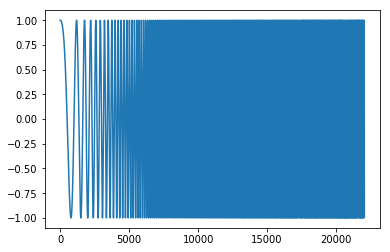

In [2]:
# 某个均衡滤波器的参数
a = np.array([1.0, -1.947463016918843, 0.9555873701383931])
b = np.array([0.9833716591860479, -1.947463016918843, 0.9722157109523452])

# 44.1kHz， 1秒的频率扫描波
t = np.arange(0, 0.5, 1/44100.0)
x= signal.chirp(t, f0=10, t1 = 0.5, f1=1000.0)

# 直接一次计算滤波器的输出
y = signal.lfilter(b, a, x)
plt.plot(x)
plt.show()

0.0


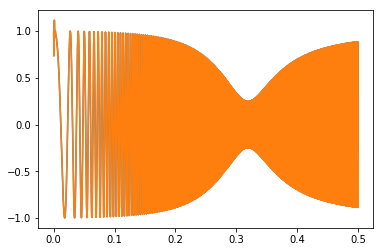

In [5]:
# 将输入信号分为50个数据一组
x2 = x.reshape((-1,50))

# 滤波器的初始状态为0， 长度是滤波器系数长度-1
z = np.zeros(max(len(a),len(b))-1, dtype=np.float)
y2 = [] # 保存输出的列表

for tx in x2:
    # 对每段信号进行滤波，并更新滤波器的状态z
    ty, z = signal.lfilter(b, a, tx, zi=z)
    # 将输出添加到输出列表中
    y2.append(ty)

# 将输出y2转换为一维数组
y2 = np.array(y2)
y2 = y2.reshape((-1,))

# 输出y和y2之间的误差
print(np.sum((y-y2)**2))

# 绘图
pl.plot(t, y, t, y2)
pl.show()

In [6]:
import numpy as np
import scipy.signal as signal


class IIR2Filter:
    def __init__(self,_order,_cutoff,*args,**kwargs):
        
        '''
            Constructor to calculate the coefficients of the filter and set up various arrays/variables
            to be used in the filter
            
            Takes in:
                _order = the order of the filter to by created
                _cutoff = the cutoff frequency(s) of the filter normalised to sample rate
            
            Optional:
                filter_type = defines if the filter is lowpass/bandpass/highpass/bandstop
                analogue_filter = defines the type of analogue filter to be replicated
                cheby_ripple = defines the acceptable ripple in a chebyshev filter in dB
                direct_form = defines if a direct form 1 or 2 filter is to be used
                fixed_point = defines if a direct form 1 filter should be fixed point
            
        '''
        
        #Check the optional arguments
        filter_type = kwargs.get('filter_type', 'low')
        analogue_filter = kwargs.get('analogue_filter', 'butter')
        cheby_ripple = kwargs.get('cheby_ripple',5)
        self.direct_form = kwargs.get('direct_form',2)
        self.fixed_point = kwargs.get('fixed_point',False)
        
        #change the cutoffs to be normalised to Nyquist rather than sample rate
        _cutoff = 2* _cutoff
           
        #select which type of analogue filter to replicate
        #output = 'sos' to give second order sections coefficients
        if analogue_filter == 'bessel':
            
            self.sos = signal.bessel(_order,_cutoff,btype=filter_type,analog=False,output='sos')
            
        elif analogue_filter == 'butter':
            
            self.sos = signal.butter(_order,_cutoff,btype=filter_type,analog=False,output='sos')
            
        elif analogue_filter == 'cheby1':
            
            self.sos = signal.cheby1(_order,cheby_ripple,_cutoff,btype=filter_type,analog=False,output='sos')
            
        elif analogue_filter == 'cheby2':
            
            self.sos = signal.cheby2(_order,cheby_ripple,_cutoff,btype=filter_type,analog=False,output='sos')
        
        
        #convert the coefficients to scaled integers if fixed point requested
        #only available for Direct Form 1
        self.fixed_scaling = 30
        if self.fixed_point==True and self.direct_form==1:
            self.sos=self.sos * (2**self.fixed_scaling)
            self.sos=self.sos.astype(int)
        
             
        #define the number of second order sections required to implement that order of filter
        shape = np.shape(self.sos)
        self.sections=shape[0]


        #set up arrays to store the x and y values for each second order section for direct form 1
        self.x=np.zeros([(self.sections),3])
        self.y=np.zeros([(self.sections),3])
        
        #set up delays for direct form 2
        self.delay=np.zeros([self.sections,2])


    def filter(self,v):
        
        '''
             Implements the IIR filtering operation element by element. Does so for
             the correct number of second order sections as defined in the constructor.
             
             
            Takes in:
                v = input data value to the filter
                
            Returns:
                result = output value from the filter
             
        '''
    
        if self.direct_form == 1:
            
            #create second order chain
            for i in range(self.sections):
            
                #load input to each IIR section
                self.x[i,0]=v
            
                buff=np.zeros(5)
                #implements the multiplications by the coefficients and stores in buffer
                buff[0]=self.sos[i,0]*self.x[i,0]
                buff[1]=self.sos[i,1]*self.x[i,1]
                buff[2]=self.sos[i,2]*self.x[i,2]
                buff[3]=-self.sos[i,4]*self.y[i,1]
                buff[4]=-self.sos[i,5]*self.y[i,2]
            
                #sums the buffers
                self.y[i,0]= np.sum(buff)
            
            
                if self.fixed_point == True:
                    
                    self.y[i,0] = int(self.y[i,0]/(2**self.fixed_scaling))
                    
            
                #shifts arrays by one for next loop
                self.x[i,2]=self.x[i,1]
                self.x[i,1]=self.x[i,0]
                self.y[i,2]=self.y[i,1]
                self.y[i,1]=self.y[i,0]
            
                #output from filter set
                v = self.y[i,0]
                
            
                 
            
        elif self.direct_form == 2:
            
            #create second order chain
            for i in range(self.sections):
                
                #implements the multiplications by the coefficients and stores in buffer
                input_acc = v - (self.delay[i,0] * self.sos[i,4]) - (self.delay[i,1] * self.sos[i,5])
                output_acc = (input_acc * self.sos[i,0]) + (self.delay[i,0] * self.sos[i,1]) + (self.delay[i,1] * self.sos[i,2])
            
                   
                #shifts arrays by one for next loop
                self.delay[i,1]=self.delay[i,0]
                self.delay[i,0]=input_acc

                #output from filter set
                v = output_acc                

        #return filter output     
        result = v
        return result

In [1]:
import numpy as np
import scipy.io.wavfile as sci
import IIR_Filter as iir


if __name__ == "__main__":
    


    sample_rate, data = sci.read('assignment3_noise_speech.wav')          #import the recorded wavefile
    data = data[:,0]                                                      #splyce out one of the audio channels
    data_ft = np.fft.fft(data)                                            #perform the fast fourier transform on the first column of data, ignore second stereo channel
    x_axis_time = np.linspace(0,len(data_ft)/sample_rate,len(data_ft))    #set the x axis to show in seconds in the time domain
    faxis = np.linspace(0,sample_rate,len(data_ft))                       #set the x axis of the frequency domain to match the sampling rate
    N=len(data)
  
        
    #set up high pass filter
    order=4                                                                      #define desired filter order
    f0 = 300/sample_rate
    f1 = 7000/sample_rate
    cut=np.array([f0,f1])                                                          #define desired cutoff frequencies
    p3 = iir.IIR2Filter(order,cut,filter_type='bandpass',analogue_filter='butter',direct_form=2)  #instantiate the class, define filter type and analogue filter
    
                   
    
    #create an array for the filtered data
    filtered_data = np.zeros(N)                                                 
    
    #loop to implement the filter    
    for i in range(N):
        filtered_data[i] = p3.filter(data[i])
   
    #Write the processed data to an output .wav file
    filtered_data = np.int16(filtered_data)
    sci.write('assignment3_part4_filtered_noise_speech.wav', sample_rate, filtered_data)

ModuleNotFoundError: No module named 'IIR_Filter'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal

In [2]:
#解决作图时中文无法显示的问题
import matplotlib.pyplot as plt
plt.rc('font', family='SimHei', size=14)
plt.rcParams['axes.unicode_minus'] = False # 解决保存图像是负号'-'显示为方块的问问题

In [3]:
def mstg():
    #产生信号序列向量st,并显示st的时域波形和频谱
    #st=mstg 返回三路调幅信号相加形成的混合信号,长度N=1600
    #N为信号st的长度
    N=800
    #采样频率Fs=10 kHz, Tp为采样时间
    Fs=10000
    T=1/Fs
    Tp=N*T
    
    t=np.arange(0,N*T,T)
    k=np.arange(0,N)
    f=k/Tp
    
    #第1路调幅信号的载波频率fc1=1000 Hz
    fc1=Fs/10
    #第1路调幅信号的调制信号频率fm1=100 Hz
    fm1=fc1/10
    
    #第2路调幅信号的载波频率fc2=500 Hz
    fc2=Fs/20
    #第2路调幅信号的调制信号频率fm2=50 Hz
    fm2=fc2/10
    
    #第3路调幅信号的载波频率fc3=250 Hz
    fc3=Fs/40
    #第3路调幅信号的调制信号频率fm3=25 Hz
    fm3=fc3/10
    
    #产生第1路调幅信号
    xt1=np.cos(2*np.pi*fm1*t)*np.cos(2*np.pi*fc1*t)
    #产生第2路调幅信号
    xt2=np.cos(2*np.pi*fm2*t)*np.cos(2*np.pi*fc2*t)
    #产生第3路调幅信号
    xt3=np.cos(2*np.pi*fm3*t)*np.cos(2*np.pi*fc3*t)
    
    #三路调幅信号相加
    st=xt1+xt2+xt3
    #计算信号st的频谱
    fxt=np.fft.fft(st,N)

    #以下为绘图部分，绘制st的时域波形和幅频特性曲线

    '''    
    fig,axxr=plt.subplots(3,1,figsize=(14,16))
    axxr[0].plot(t,st)
    axxr[0].set_title("(a) s(t)的波形")
    axxr[0].set_xlabel("t/s")
    axxr[0].set_ylabel("s(t)")
    axxr[1].stem(f,abs(fxt)/np.max(abs(fxt)),'--')
    axxr[1].set_title("(b) s(t)的频谱")
    axxr[1].set_xlabel("f/Hz")
    axxr[1].set_ylabel("幅度")
    '''

    return st

In [8]:
#时域离散系统损耗函数绘图
def myplot(B,A):
    #B为系统函数分子多项式系数向量
    #A为系统函数分母多项式系数向量
    #计算数字滤波器的频率响应
    [H,W]=signal.freqz(B,A,1000)        #数字滤波器的频率响应
    #y1=np.fft.fft(B,A,st)
    #plt.plot(np.arange(len(y1))/fs,y1)
    #plt.plot(W,20*np.log10(max(abs(H))/(abs(H))))
    plt.plot(W,20*np.log10(abs(H)))
    plt.grid(True)
    plt.xlabel("\omega/\pi")
    plt.ylabel('幅度(dB)')
    plt.title('损耗函数曲线')

In [9]:
#时域序列连续曲线绘图函数
def tplot(xn,T,yn):
    #xn：信号数据序列，yn：绘图信号的纵坐标名字(字符串)
    #T为采样间隔
    n=np.arange(len(xn))
    t=n*T
    plt.plot(t,xn)
    plt.xlabel("t/s")
    plt.ylabel(yn)
    #plt.title("滤波后的时域波形")

In [10]:
#IIR数字滤波器设计及软件实现
#采样频率
Fs=10000
T=1/Fs
#调用信号产生函数mstg产生由三路抑制载波调幅信号相加构成的复合信号st 
st=mstg()

D:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in log10
  # Remove the CWD from sys.path while we load stuff.
D:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\numpy\core\numeric.py:492: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


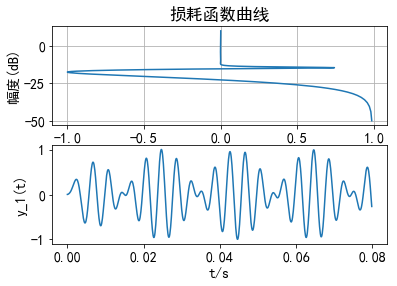

In [11]:
#低通滤波器设计与实现=========================
#DF指标（低通滤波器的通、 阻带边界频率）
fp=280
fs=450;
wp=2*fp/Fs
ws=2*fs/Fs
rp=0.1
rs=60;    
#调用ellipord计算椭圆DF阶数N和通带截止频率wp
[N,wp]=signal.ellipord(wp,ws,rp,rs);      
#调用ellip计算椭圆带通DF系统函数系数向量B和A
[B,A]=signal.ellip(N,rp,rs,wp);  
#低通滤波器设计与实现绘图部分
#调用绘图函数myplot绘制损耗函数曲线
plt.subplot(2,1,1);
myplot(B,A);
#滤波器软件实现
y1t=signal.lfilter(B,A,st);    
#调用绘图函数tplot绘制滤波器输出波形
yt='y_1(t)';
plt.subplot(2,1,2);
tplot(y1t,T,yt);  

In [8]:
#带通滤波器设计与实现=========================
fpl=440;
fpu=560;
fsl=275;
fsu=900;
wp=[2*fpl/Fs,2*fpu/Fs]; 
ws=[2*fsl/Fs,2*fsu/Fs];
rp=0.1;
rs=60; 
#调用ellipord计算椭圆DF阶数N和通带截止频率wp
[N,wp]=signal.ellipord(wp,ws,rp,rs);
#调用ellip计算椭圆带通DF系统函数系数向量B和A
#[B,A]=signal.ellip(N,rp,rs,wp); 
[B,A]=signal.ellip(N,rp,rs,wp,'bandpass');
#滤波器软件实现
y2t=signal.lfilter(B,A,st);     

D:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in true_divide
  if __name__ == '__main__':
D:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\numpy\core\numeric.py:492: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


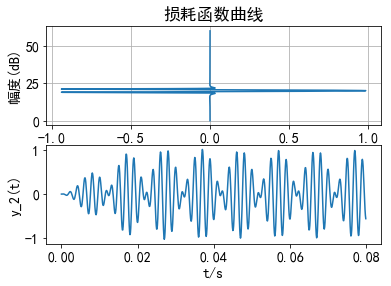

In [9]:
#带通滤波器设计与实现绘图部分
#调用绘图函数myplot绘制损耗函数曲线
plt.subplot(2,1,1);
myplot(B,A);
#调用绘图函数tplot绘制滤波器输出波形
yt='y_2(t)';
plt.subplot(2,1,2);
tplot(y2t,T,yt);      

In [10]:
#高通滤波器设计与实现===========================
fp=890;
fs=600;
wp=2*fp/Fs; 
ws=2*fs/Fs;
rp=0.1;
rs=60;    
#DF指标（低通滤波器的通、 阻带边界频率）
#调用ellipord计算椭圆DF阶数N和通带%截止频率wp
[N,wp]=signal.ellipord(wp,ws,rp,rs);     
#调用ellip计算椭圆带通DF系统函数系数向量B和A
[B,A]=signal.ellip(N,rp,rs,wp,'high');  
#滤波器软件实现
y3t=signal.lfilter(B,A,st); 

D:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in true_divide
  if __name__ == '__main__':
D:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\numpy\core\numeric.py:492: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


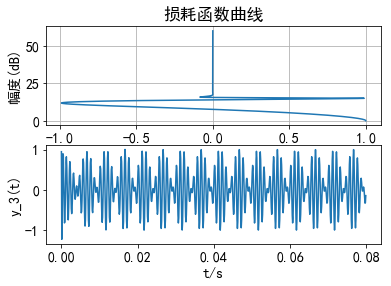

In [11]:
#高低通滤波器设计与实现绘图部分
#调用绘图函数myplot绘制损耗函数曲线
plt.subplot(2,1,1);
myplot(B,A);
#调用绘图函数tplot绘制滤波器输出波形
yt='y_3(t)';
plt.subplot(2,1,2);
tplot(y3t,T,yt);    